# Extracción de datos API
El proceso de extracción de datos para la RRSS de Instagram ha sido algo diferente que TikTok. Se ha decidido buscar por diferentes hashtags y luego filtrar por número de comentarios y likes de cada post/reel de instagram para luego de cada post extraer los comentarios

### Extracción de reels

In [ ]:
from apify_client import ApifyClient
import pandas as pd
import json

from dotenv import load_dotenv
import os

load_dotenv()
APIFY_TOKEN = os.getenv("APIFY_TOKEN")

run = client.actor("apify/instagram-hashtag-scraper").call(run_input={
    "hashtags": ["donarsangre", "donacionsangre", "donarsangreespaña", "donacionsangreespaña"],
    "resultsType": "reels",      # o "reels"
    "resultsLimit": 50           # por hashtag
})

items = list(client.dataset(run["defaultDatasetId"]).iterate_items())

# Guardar JSON
with open("ig_hashtags.json", "w", encoding="utf-8") as f:
    json.dump(items, f, ensure_ascii=False, indent=2)

# Guardar CSV
pd.DataFrame(items).to_csv("ig_hashtags.csv", index=False)

print("Items:", len(items))
print("Dataset:", run["defaultDatasetId"])

Items: 62
Dataset: r8cPqU0bgWcMZ3vig


### Extracción de posts

In [ ]:
client = ApifyClient(APIFY_TOKEN)

run = client.actor("apify/instagram-hashtag-scraper").call(run_input={
    "hashtags": ["donarsangre", "donacionsangre", "donarsangreespaña", "donacionsangreespaña"],
    "resultsType": "posts",      # o "reels"
    "resultsLimit": 50           # por hashtag
})

items = list(client.dataset(run["defaultDatasetId"]).iterate_items())

# Guardar JSON
with open("ig_hashtags_posts.json", "w", encoding="utf-8") as f:
    json.dump(items, f, ensure_ascii=False, indent=2)

# Guardar CSV
pd.DataFrame(items).to_csv("ig_hashtags_posts.csv", index=False)

print("Items:", len(items))
print("Dataset:", run["defaultDatasetId"])

Items: 57
Dataset: 0Wx33NnYdgXcDVAS7


### Analizar los datos resultantes para extraer los comentarios de los mejores posts/videos y los más recientes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

REELS_PATH = "ig_hashtags.csv"
POSTS_PATH = "ig_hashtags_posts.csv"

def parse_hashtags(x):
    """
    Convierte la columna hashtags a lista.
    Puede venir como:
    - lista real
    - string estilo "['a','b']"
    - string tipo "#a #b"
    - NaN
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(t).lower().strip() for t in x]
    if isinstance(x, str):
        s = x.strip()
        # Caso "['a','b']"
        if s.startswith("[") and s.endswith("]"):
            try:
                vals = ast.literal_eval(s)
                if isinstance(vals, list):
                    return [str(t).lower().strip() for t in vals]
            except Exception:
                pass
        # Caso "#a #b"
        s = s.replace("#", " ")
        parts = [p.lower().strip() for p in s.split() if p.strip()]
        return parts
    return []

def load_and_standardize(path, kind):
    df = pd.read_csv(path)
    df["kind"] = kind  # reel/post

    # ---- Column mapping (por si cambian nombres) ----
    col_map_candidates = {
        "url": ["url", "postUrl", "postURL", "link"],
        "timestamp": ["timestamp", "takenAt", "takenAtTimestamp", "createdAt", "date"],
        "likes": ["likesCount", "likeCount", "likes", "likes_count"],
        "comments": ["commentsCount", "commentCount", "comments", "comments_count"],
        "caption": ["caption", "text", "description"],
        "shortCode": ["shortCode", "shortcode", "code"],
        "type": ["type", "productType"]
    }

    def pick_col(cands):
        for c in cands:
            if c in df.columns:
                return c
        return None

    chosen = {k: pick_col(v) for k, v in col_map_candidates.items()}

    # ---- Columnas estándar ----
    df["url_std"] = df[chosen["url"]].astype(str) if chosen["url"] else ""
    df["caption_std"] = df[chosen["caption"]].astype(str) if chosen["caption"] else ""

    df["likes_std"] = pd.to_numeric(df[chosen["likes"]], errors="coerce").fillna(0).astype(int) if chosen["likes"] else 0
    df["comments_std"] = pd.to_numeric(df[chosen["comments"]], errors="coerce").fillna(0).astype(int) if chosen["comments"] else 0

    # ---- timestamp ----
    ts_col = chosen["timestamp"]
    if ts_col:
        if pd.api.types.is_numeric_dtype(df[ts_col]):
            df["timestamp_std"] = pd.to_datetime(df[ts_col], unit="s", errors="coerce")
        else:
            df["timestamp_std"] = pd.to_datetime(df[ts_col], errors="coerce", utc=True).dt.tz_convert(None)
    else:
        df["timestamp_std"] = pd.NaT

    df["year"] = df["timestamp_std"].dt.year
    df["month"] = df["timestamp_std"].dt.to_period("M").astype(str)

    # ---- score ----
    df["score"] = (df["comments_std"] * 3) + (df["likes_std"] * 1)

    # ---- NUEVO: hashtags + location ----
    if "hashtags" in df.columns:
        df["hashtags_list"] = df["hashtags"].apply(parse_hashtags)
    else:
        df["hashtags"] = np.nan
        df["hashtags_list"] = [[] for _ in range(len(df))]

    # ---- NUEVO: campos extra si existen ----
    extra_cols = [
        "inputUrl", "shortCode", "type", "productType",
        "ownerUsername", "ownerFullName", "ownerId",
        "locationName", "locationId",
        "videoUrl", "videoPlayCount", "igPlayCount",
        "musicInfo"
    ]
    for c in extra_cols:
        if c not in df.columns:
            df[c] = np.nan

    # ---- Columnas finales (std + extra útiles) ----
    keep = [
        "kind",
        "url_std", "shortCode",
        "likes_std", "comments_std", "score",
        "timestamp_std", "year", "month",
        "caption_std",
        "hashtags", "hashtags_list",
        "inputUrl",
        "ownerUsername", "ownerFullName", "ownerId",
        "locationName", "locationId",
        "type", "productType",
        "videoUrl", "videoPlayCount", "igPlayCount",
        "musicInfo"
    ]

    return df[keep].copy()

reels = load_and_standardize(REELS_PATH, "reel")
posts = load_and_standardize(POSTS_PATH, "post")

df_all = pd.concat([reels, posts], ignore_index=True)

print("Reels:", len(reels), "Posts:", len(posts), "Total:", len(df_all))
df_all.head()

Reels: 62 Posts: 57 Total: 119


,kind,url_std,shortCode,likes_std,comments_std,score,timestamp_std,year,month,caption_std,...,ownerFullName,ownerId,locationName,locationId,type,productType,videoUrl,videoPlayCount,igPlayCount,musicInfo
0,reel,https://www.instagram.com/explore/tags/donacio...,NaN,0,0,0,NaT,NaN,NaT,nan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,reel,https://www.instagram.com/explore/tags/donarsa...,NaN,0,0,0,NaT,NaN,NaT,nan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,reel,https://www.instagram.com/p/C0uB77jODQu/,C0uB77jODQu,8,0,8,2023-12-11 16:20:17,2023.0,2023-12,En el ADN de Keller Williams Kinver está en se...,...,Angel Sánchez,4.306205e+09,NaN,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,237.0,237.0,"{'artist_name': 'angel.sanchezvinas', 'song_na..."
3,reel,https://www.instagram.com/p/CkI7SeSDfvh/,CkI7SeSDfvh,0,0,0,2022-10-25 14:09:18,2022.0,2022-10,TOMEMOS CONCIENCIA QUE CON SOLO UN PINCHAZITO ...,...,Juan Ignacio Schaab,4.910319e+09,Plaza Houssay,5.000042e+14,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,56.0,56.0,"{'artist_name': 'jischaab', 'song_name': 'Orig..."
4,reel,https://www.instagram.com/p/DI-fKMfsEQR/,DI-fKMfsEQR,4,0,4,2025-04-28 04:18:24,2025.0,2025-04,#donantesdemedulaosea #donacion #fundacioncarr...,...,DOMENA Donantes de Médula,5.546416e+10,NaN,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,445.0,445.0,"{'artist_name': 'imparablescontralaleucemia', ..."


In [3]:
df_all["locationName"].notna().sum()

29

In [4]:
df_all["locationName"].dropna().value_counts().head(29)

locationName
Fundación Favaloro                                         3
Barbastro                                                  2
Colegio San Vicente de Paúl - Alcoy                        2
Entrepuentes                                               2
Hospital Central de la Cruz Roja San José y Santa Adela    1
Culiacán, Sinaloa                                          1
San Felix Ikastola                                         1
La Nucía                                                   1
Madrid, Spain                                              1
Plaça Sant Jaume                                           1
Queretaro                                                  1
Clínica Piedra Azul                                        1
Somewhere Around the Globe                                 1
Plaza Houssay                                              1
Cadiz-San Fernando                                         1
Iglesia Adventista Maranatha Cali                          1
Villa Devot

In [5]:
from collections import Counter

all_tags = []
for tags in df_all["hashtags_list"]:
    all_tags.extend(tags)

Counter(all_tags)

Counter({'granada': 3,
         'kwkinver': 3,
         'kellerwilliams': 3,
         'inmobiliariadegranada': 3,
         'inmobiliariasdegranada': 3,
         'granadainmo': 3,
         'granadainmobiliarias': 3,
         'agenteinmobiliario': 3,
         'emprendimientogranada': 3,
         'jovenesempresarios': 3,
         'jovenesempresariosdegranada': 3,
         'realestateagent': 3,
         'empresariosgranadinos': 3,
         'realtor': 3,
         'luxury': 3,
         'lifestyle': 4,
         'visionofcareer': 3,
         'venta': 3,
         'comprar': 1,
         'feliznavidad': 3,
         'felicesfiestas': 3,
         'navidad': 3,
         'navidad2023': 1,
         'navidadkinver': 3,
         'donacionsangre': 54,
         'octubre': 1,
         'dalevida': 1,
         'darvidaenvida': 2,
         'salvovidas': 1,
         'sangre': 7,
         'donantedesangre': 2,
         'donantevoluntario': 2,
         'solidaridad': 13,
         'donásangre': 1,
         'donar

In [6]:
hashtags_excluir = [
    # Veterinaria / animales
    "perros", "gatos", "animales", "vet", "mascotas",
    "clinicaveterinaria", "medicinaveterinaria", "oncologiaveterinaria",
    "pethealth", "doghealthtip", "dogwellness", "saludcanina",
    "vitalvet", "veterinariansofinstagram", "cirugíaveterinaria",
    "bancodesangreveterinario", "oncovet", "onivet",

    # Inmobiliaria / marketing
    "kellerwilliams", "realestateagent", "realtor",
    "inmobiliaria", "granadainmo", "luxury", "lifestyle",

    # 🇲🇽 Países latinoamericanos
    "mexico", "argentina", "colombia", "peru", "venezuela",
    "chiapas", "queretaro", "caracas", "maracay", "cdmx",
    "bogotasangre", "mardelplata", "quilmes", "berazategui",

    # Humor / no sanitario
    "standup", "standupcomedy", "humor", "chistes", "humillacion",

    # Otros no relevantes
    "marykay", "jetset", "rubbyperez"
]

In [7]:
df_clean = df_all[
    ~df_all["hashtags_list"].apply(
        lambda tags: any(tag in hashtags_excluir for tag in tags)
    )
].copy()

print("Antes:", len(df_all))
print("Después de limpieza:", len(df_clean))

Antes: 119
Después de limpieza: 94


In [8]:
# Ordenamos por comentarios (puedes cambiar a likes si prefieres)
df_all = df_clean.sort_values("comments_std", ascending=False).reset_index(drop=True)

# Crear identificador numerado por tipo
df_all["rank_global"] = range(1, len(df_all) + 1)

# Crear contador separado para posts y reels
df_all["rank_type"] = df_all.groupby("kind").cumcount() + 1

# Crear etiqueta legible
df_all["label"] = df_all.apply(
    lambda row: f"{row['kind'].capitalize()} {row['rank_type']}",
    axis=1
)

df_all[["label", "kind", "likes_std", "comments_std"]].head()

,label,kind,likes_std,comments_std
0,Reel 1,reel,89170,1412
1,Reel 2,reel,2276,243
2,Reel 3,reel,10269,237
3,Reel 4,reel,994,138
4,Reel 5,reel,772,81


In [9]:
df_all.head()

,kind,url_std,shortCode,likes_std,comments_std,score,timestamp_std,year,month,caption_std,...,locationId,type,productType,videoUrl,videoPlayCount,igPlayCount,musicInfo,rank_global,rank_type,label
0,reel,https://www.instagram.com/p/C5s95qvijpq/,C5s95qvijpq,89170,1412,93406,2024-04-13 13:03:35,2024.0,2024-04,¡Tu donación de sangre salva vidas! 💖💉 Se nece...,...,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,1350779.0,1333332.0,"{'artist_name': 'nachter', 'song_name': 'Origi...",1,1,Reel 1
1,reel,https://www.instagram.com/p/DTqavUIjOZN/,DTqavUIjOZN,2276,243,3005,2026-01-18 18:55:52,2026.0,2026-01,🩸💉 Cada vez que te sacan sangre (en una donaci...,...,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,28248.0,28248.0,"{'artist_name': 'celulau.bio', 'song_name': 'O...",2,2,Reel 2
2,reel,https://www.instagram.com/p/DUSDNdDDPWo/,DUSDNdDDPWo,10269,237,10980,2026-02-03 04:18:00,2026.0,2026-02,Influencer pide ayuda urgente para @_la_riri\n...,...,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,221954.0,221954.0,"{'artist_name': 'noticias_lfc', 'song_name': '...",3,3,Reel 3
3,reel,https://www.instagram.com/p/CqvcnnANcpK/,CqvcnnANcpK,994,138,1408,2023-04-07 16:24:00,2023.0,2023-04,HASTA SIEMPRE JES !\n\nMe quedo con tus consej...,...,605978336.0,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,12584.0,12063.0,"{'artist_name': 'marcelocasoy', 'song_name': '...",4,4,Reel 4
4,reel,https://www.instagram.com/p/DTx234ZjQXb/,DTx234ZjQXb,772,81,1015,2026-01-21 16:15:00,2026.0,2026-01,.\n\nMe sale del corazón y del alma intentar a...,...,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,25960.0,25960.0,"{'artist_name': 'sietenfamilia', 'song_name': ...",5,5,Reel 5


### Visualizaciones: likes y comentarios (distribución)

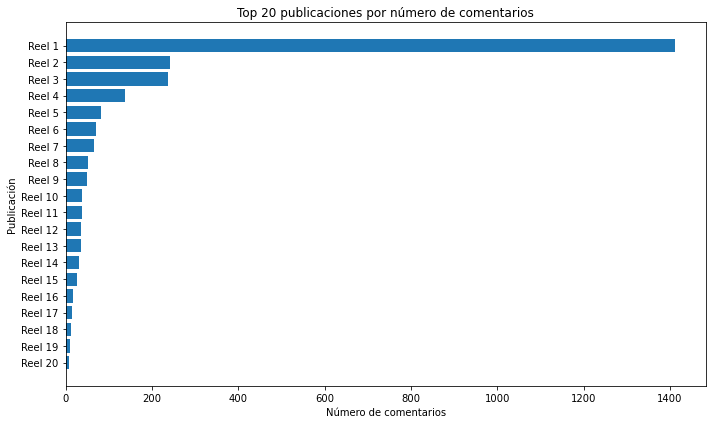

In [10]:
top_comments = df_all.sort_values("comments_std", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_comments["label"], top_comments["comments_std"])
plt.gca().invert_yaxis()
plt.title("Top 20 publicaciones por número de comentarios")
plt.xlabel("Número de comentarios")
plt.ylabel("Publicación")
plt.tight_layout()
plt.show()

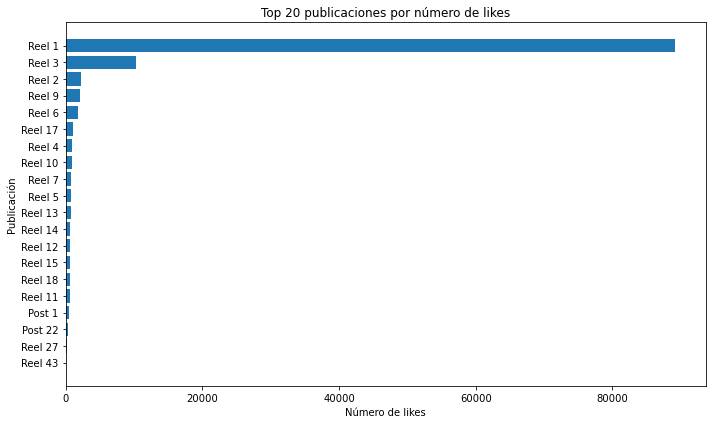

In [11]:
top_likes = df_all.sort_values("likes_std", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_likes["label"], top_likes["likes_std"])
plt.gca().invert_yaxis()
plt.title("Top 20 publicaciones por número de likes")
plt.xlabel("Número de likes")
plt.ylabel("Publicación")
plt.tight_layout()
plt.show()

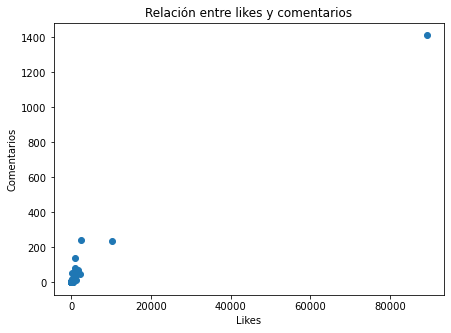

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(df_all["likes_std"], df_all["comments_std"])
plt.title("Relación entre likes y comentarios")
plt.xlabel("Likes")
plt.ylabel("Comentarios")
plt.show()

### Distribución de reels/post por año

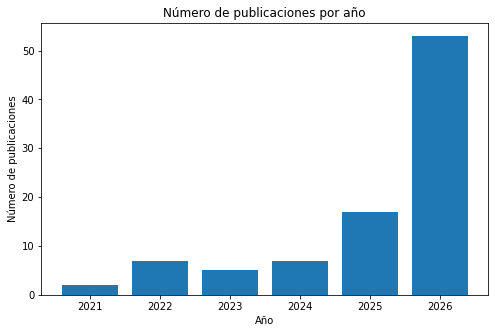

In [13]:
counts_year = df_all.groupby("year").size().reset_index(name="n")

plt.figure(figsize=(8,5))
plt.bar(counts_year["year"], counts_year["n"])
plt.title("Número de publicaciones por año")
plt.xlabel("Año")
plt.ylabel("Número de publicaciones")
plt.show()

### Engagement combinado de estas tres variables: numero de likes, comentarios y año

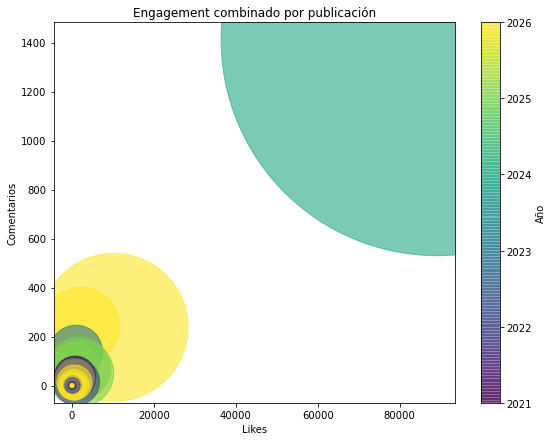

In [14]:
import numpy as np

plt.figure(figsize=(9,7))

sizes = df_all["score"] * 2  # ajusta multiplicador si queda pequeño

scatter = plt.scatter(
    df_all["likes_std"],
    df_all["comments_std"],
    s=sizes,
    c=df_all["year"],
    alpha=0.6
)

plt.xlabel("Likes")
plt.ylabel("Comentarios")
plt.title("Engagement combinado por publicación")
plt.colorbar(scatter, label="Año")
plt.show()

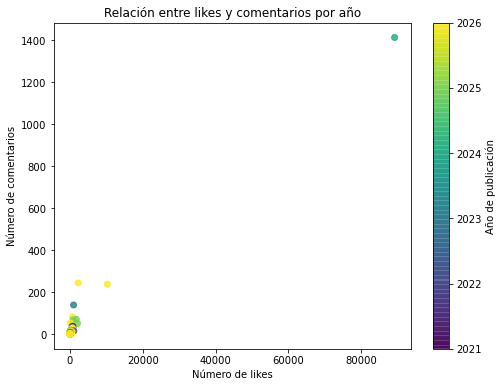

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_all["likes_std"],
    df_all["comments_std"],
    c=df_all["year"],
    cmap="viridis",
    alpha=0.8
)

plt.xlabel("Número de likes")
plt.ylabel("Número de comentarios")
plt.title("Relación entre likes y comentarios por año")

cbar = plt.colorbar(scatter)
cbar.set_label("Año de publicación")

plt.show()

In [17]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_plot["likes_std"],
    df_plot["comments_std"],
    c=df_plot["year"],
    cmap="viridis",
    alpha=0.8
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Likes (escala log)")
plt.ylabel("Comentarios (escala log)")
plt.title("Relación likes vs comentarios (log-log)")

cbar = plt.colorbar(scatter)
cbar.set_label("Año de publicación")

plt.tight_layout()
plt.show()

NameError: name 'df_plot' is not defined

<Figure size 576x432 with 0 Axes>

In [15]:
df_all.sort_values(
    ["likes_std", "comments_std"],
    ascending=False
)[["label","kind","likes_std","comments_std","year"]].head(8)

,label,kind,likes_std,comments_std,year
0,Reel 1,reel,89170,1412,2024.0
2,Reel 3,reel,10269,237,2026.0
1,Reel 2,reel,2276,243,2026.0
8,Reel 9,reel,2076,50,2025.0
5,Reel 6,reel,1751,70,2025.0
16,Reel 17,reel,1048,15,2022.0
3,Reel 4,reel,994,138,2023.0
9,Reel 10,reel,950,37,2025.0


In [16]:
selected_labels = [
    "Reel 1",
    "Reel 2",
    "Reel 3",
    "Reel 9",
    "Reel 6",
    "Reel 4"
]

df_selected = df_all[df_all["label"].isin(selected_labels)]

df_selected[["label", "kind", "likes_std", "comments_std", "year", "caption_std", "url_std"]]

,label,kind,likes_std,comments_std,year,caption_std,url_std
0,Reel 1,reel,89170,1412,2024.0,¡Tu donación de sangre salva vidas! 💖💉 Se nece...,https://www.instagram.com/p/C5s95qvijpq/
1,Reel 2,reel,2276,243,2026.0,🩸💉 Cada vez que te sacan sangre (en una donaci...,https://www.instagram.com/p/DTqavUIjOZN/
2,Reel 3,reel,10269,237,2026.0,Influencer pide ayuda urgente para @_la_riri\n...,https://www.instagram.com/p/DUSDNdDDPWo/
3,Reel 4,reel,994,138,2023.0,HASTA SIEMPRE JES !\n\nMe quedo con tus consej...,https://www.instagram.com/p/CqvcnnANcpK/
5,Reel 6,reel,1751,70,2025.0,🙏🏻No solo Segu necesita un donante !! Muchos n...,https://www.instagram.com/p/DRyD8WLAPoE/
8,Reel 9,reel,2076,50,2025.0,La importancia de la DONACIÓN de SANGRE y sus ...,https://www.instagram.com/p/DIHUlQpPc0a/


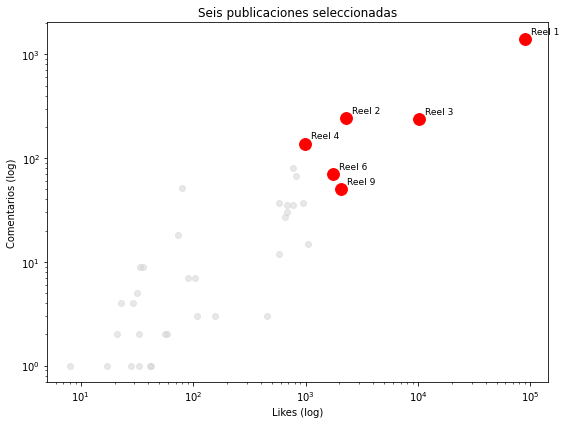

In [17]:
import matplotlib.pyplot as plt

df_plot = df_all[
    (df_all["likes_std"] > 0) &
    (df_all["comments_std"] > 0)
]

plt.figure(figsize=(8,6))

# Todos en gris
plt.scatter(
    df_plot["likes_std"],
    df_plot["comments_std"],
    color="lightgrey",
    alpha=0.5
)

# Seleccionados destacados
plt.scatter(
    df_selected["likes_std"],
    df_selected["comments_std"],
    color="red",
    s=140
)

# Etiquetas
for _, row in df_selected.iterrows():
    plt.annotate(
        row["label"],
        (row["likes_std"], row["comments_std"]),
        textcoords="offset points",
        xytext=(6,5),
        fontsize=9
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Likes (log)")
plt.ylabel("Comentarios (log)")
plt.title("Seis publicaciones seleccionadas")

plt.tight_layout()
plt.show()

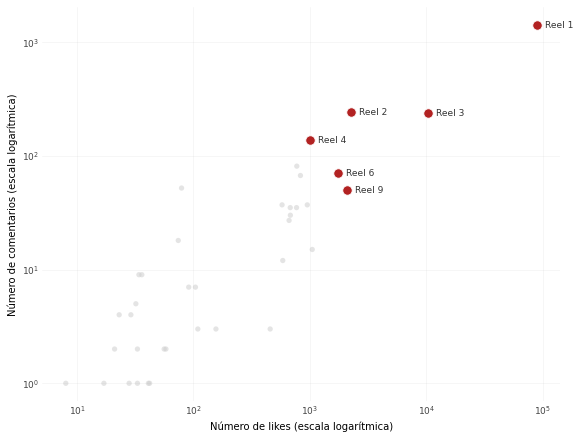

In [21]:
import matplotlib.pyplot as plt

df_plot = df_all[
    (df_all["likes_std"] > 0) &
    (df_all["comments_std"] > 0)
]

fig, ax = plt.subplots(figsize=(8.2, 6.2))

# Nube general
ax.scatter(
    df_plot["likes_std"],
    df_plot["comments_std"],
    s=28,
    color="#cfcfcf",
    alpha=0.55,
    edgecolors="none"
)

# Seleccionados
ax.scatter(
    df_selected["likes_std"],
    df_selected["comments_std"],
    s=90,
    color="#b22222",
    edgecolors="white",
    linewidths=0.9,
    zorder=3
)

# Etiquetas
for _, row in df_selected.iterrows():
    ax.annotate(
        row["label"],
        xy=(row["likes_std"], row["comments_std"]),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        color="#333333"
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Número de likes (escala logarítmica)", fontsize=10)
ax.set_ylabel("Número de comentarios (escala logarítmica)", fontsize=10)

# Quitar marco entero
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid suave solo principal
ax.grid(True, which="major", linestyle="-", linewidth=0.6, alpha=0.18)
ax.grid(False, which="minor")

# Ticks discretos
ax.tick_params(axis="both", which="both", length=0, labelsize=9, colors="#444444")

# Fondo blanco limpio
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.show()

## Extracción de los comentarios de estos 6 reels
Se ha decidido hacer una selección para obtener los comentarios de aquellas publicaciones que tengan un número de likes elevado y que hablen de donación de sangre

In [22]:
selected_urls = df_selected["url_std"].dropna().unique().tolist()
selected_urls

['https://www.instagram.com/p/C5s95qvijpq/',
 'https://www.instagram.com/p/DTqavUIjOZN/',
 'https://www.instagram.com/p/DUSDNdDDPWo/',
 'https://www.instagram.com/p/CqvcnnANcpK/',
 'https://www.instagram.com/p/DRyD8WLAPoE/',
 'https://www.instagram.com/p/DIHUlQpPc0a/']

### Opción: Actor Apify Instagram Scraper (comentarios por URL de post)

Puedes usar el **Actor de Apify** para extraer comentarios de los 6 reels desde sus URLs (requiere créditos en Apify).

- **Actor ID:** `SbK00X0JYCPblD2wp`
- **Input:** `directUrls` (lista de URLs), `resultsLimit`, `isNewestComments`, `includeNestedComments`. Ver [Input del actor](https://console.apify.com/actors/SbK00X0JYCPblD2wp/input).
- **Token:** el mismo que usas arriba para el hashtag scraper.

In [ ]:
# Extracción de comentarios con el Actor Apify (ID: SbK00X0JYCPblD2wp)
# Input: https://console.apify.com/actors/SbK00X0JYCPblD2wp/input
from apify_client import ApifyClient
import pandas as pd

from dotenv import load_dotenv
import os

load_dotenv()
APIFY_TOKEN = os.getenv("APIFY_TOKEN")

ACTOR_ID = "SbK00X0JYCPblD2wp"

client = ApifyClient(APIFY_TOKEN)

run_input = {
    "directUrls": selected_urls,
    "resultsLimit": 2500,
    "includeNestedComments": True,
}

run = client.actor(ACTOR_ID).call(run_input=run_input)

# Recoger resultados del dataset (estructura depende del actor: puede ser 1 item por post con "comments" o 1 por comentario)
rows = []
for item in client.dataset(run["defaultDatasetId"]).iterate_items():
    if isinstance(item, dict):
        if "comments" in item:
            post_url = item.get("url") or item.get("postUrl") or item.get("post_url") or ""
            for c in item.get("comments") or []:
                if isinstance(c, dict):
                    rows.append({
                        "post_url": post_url,
                        "comment_id": c.get("id"),
                        "text": c.get("text") or c.get("message"),
                        "username": (c.get("owner") or c.get("user") or {}).get("username", "") if isinstance(c.get("owner") or c.get("user"), dict) else "",
                    })
                elif isinstance(c, str):
                    rows.append({"post_url": post_url, "comment_id": "", "text": c, "username": ""})
        elif item.get("type") == "comment" or "text" in item or "message" in item:
            rows.append({
                "post_url": item.get("postUrl") or item.get("post_url") or "",
                "comment_id": item.get("id"),
                "text": item.get("text") or item.get("message", ""),
                "username": (item.get("user") or item.get("owner") or {}).get("username", "") if isinstance(item.get("user") or item.get("owner"), dict) else "",
            })

df_comments_apify = pd.DataFrame(rows)
out_path = "instagram_comentarios_reels_apify.csv"
df_comments_apify.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Comentarios extraídos: {len(df_comments_apify)}. Guardado en {out_path}")
df_comments_apify.head(10)

Comentarios extraídos: 1368. Guardado en instagram_comentarios_reels_apify.csv


,post_url,comment_id,text,username
0,https://www.instagram.com/p/DRyD8WLAPoE/,18414420817136831,"Excelente video!! Fuerzas Jessi, comparto 🫂",albavelazq
1,https://www.instagram.com/p/DRyD8WLAPoE/,18210521863313862,Bendiciones familia!!!! Vamos Segun!!!💪💪,esenciamiaropainformal
2,https://www.instagram.com/p/DRyD8WLAPoE/,17864457456531315,Compartido!!!! Vamos Segu❤️🙌,maruvallet
3,https://www.instagram.com/p/DRyD8WLAPoE/,18094510561712976,Vamos amigos ! Ya saben cuánto los quiero ❤️,alexiayaelc
4,https://www.instagram.com/p/DRyD8WLAPoE/,18165615250391418,Compartido ❤️❤️❤️,kinesiologiamujer
5,https://www.instagram.com/p/DRyD8WLAPoE/,18081560798127620,Un abrazo fuerte! 🙌❤️,merce_557
6,https://www.instagram.com/p/DRyD8WLAPoE/,18071086061584419,Jesi! A donde nos podemos acercar para donar?,indindiyaindu
7,https://www.instagram.com/p/DRyD8WLAPoE/,18549448237006482,Ya soy donante de médula desde el 2015!! Que l...,ericastrillook
8,https://www.instagram.com/p/DRyD8WLAPoE/,18137074948467840,Muchas fuerzas para toda la familia. Los que...,diemol2107
9,https://www.instagram.com/p/DRyD8WLAPoE/,18295962406275707,"Hace unos 10 años que soy donante, si bien lo...",mannu202


In [27]:
# Resumen: cuántas URLs distintas hay y cuántos comentarios por cada una
if "post_url" in df_comments_apify.columns and len(df_comments_apify) > 0:
    n_urls = df_comments_apify["post_url"].nunique()
    print(f"URLs distintas (posts): {n_urls}")
    print(f"Total filas (comentarios): {len(df_comments_apify)}\n")
    print("Comentarios por post_url:")
    display(df_comments_apify["post_url"].value_counts().to_frame(name="n_comentarios"))
else:
    print("No hay columna post_url o el DataFrame está vacío.")

URLs distintas (posts): 6
Total filas (comentarios): 1368

Comentarios por post_url:


,n_comentarios
post_url,
https://www.instagram.com/p/C5s95qvijpq/,903
https://www.instagram.com/p/CqvcnnANcpK/,137
https://www.instagram.com/p/DRyD8WLAPoE/,128
https://www.instagram.com/p/DTqavUIjOZN/,112
https://www.instagram.com/p/DIHUlQpPc0a/,47
https://www.instagram.com/p/DUSDNdDDPWo/,41


In [25]:
reel1 = df_selected["url_std"].iloc[0]

In [25]:
import pandas as pd

# Leer el CSV original
df = pd.read_csv("descarga_instagram.csv")

# Columnas que quieres conservar
columnas_interes = [
    "postUrl",
    "id",
    "text",
    "timestamp",
    "likesCount",
    "repliesCount",
    "ownerUsername",
    "owner/full_name",
    "owner/id",
    "owner/is_verified",
    "owner/is_private"
]

# Quedarte solo con las que realmente existan en el archivo
columnas_existentes = [col for col in columnas_interes if col in df.columns]

df_filtrado = df[columnas_existentes].copy()

# Guardar en un nuevo CSV
df_filtrado.to_csv("instagram_columnas_filtradas.csv", index=False, encoding="utf-8-sig")

print("Columnas guardadas:", columnas_existentes)
print("Archivo creado: instagram_columnas_filtradas.csv")
df_filtrado.head()

Columnas guardadas: ['postUrl', 'id', 'text', 'timestamp', 'likesCount', 'repliesCount', 'ownerUsername', 'owner/full_name', 'owner/id', 'owner/is_verified', 'owner/is_private']
Archivo creado: instagram_columnas_filtradas.csv


,postUrl,id,text,timestamp,likesCount,repliesCount,ownerUsername,owner/full_name,owner/id,owner/is_verified,owner/is_private
0,https://www.instagram.com/p/DRyD8WLAPoE/,18414420817136831,"Excelente video!! Fuerzas Jessi, comparto 🫂",2025-12-03T15:19:46.000Z,2,0,albavelazq,Alba velazquez,331434742,False,True
1,https://www.instagram.com/p/DRyD8WLAPoE/,18210521863313862,Bendiciones familia!!!! Vamos Segun!!!💪💪,2025-12-03T01:36:57.000Z,4,0,esenciamiaropainformal,ESENCIA MÍA 👗 | Any Blanco,1960113903,False,False
2,https://www.instagram.com/p/DRyD8WLAPoE/,17864457456531315,Compartido!!!! Vamos Segu❤️🙌,2025-12-03T10:19:52.000Z,2,0,maruvallet,Maru Vallet,3114282536,False,True
3,https://www.instagram.com/p/DRyD8WLAPoE/,18094510561712976,Vamos amigos ! Ya saben cuánto los quiero ❤️,2025-12-04T01:33:53.000Z,2,0,alexiayaelc,Alexia Yael Caceres Baes,5494609535,False,True
4,https://www.instagram.com/p/DRyD8WLAPoE/,18165615250391418,Compartido ❤️❤️❤️,2025-12-03T15:08:48.000Z,2,0,kinesiologiamujer,KIM | Kinesiología de Piso Pélvico para todxs,6269617973,False,False
